# Wine Quality Prediction Analysis
## 1. Project Overview
This notebook analyzes the `winequalityN.csv` dataset to predict wine quality. 
The process includes:
* **Data Cleaning:** Handling missing values.
* **Feature Engineering:** Converting categorical types to numerical data.
* **Exploratory Analysis:** Using correlation heatmaps to identify key drivers.
* **Model Training:** Implementing a Random Forest classifier.

In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv('winequalityN.csv')

# Drop missing values
df = df.dropna()

# Convert 'type' (red/white) to numerical (0/1)
df = pd.get_dummies(df, columns=['type'], drop_first=True)

# Verify the changes
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_white
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,True
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,True
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,True
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,True
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,True


## 2. Exploratory Data Analysis (EDA)
In this section, we examine the relationships between chemical properties 
and the final quality score. 
> **Note:** We are specifically looking for features that show strong correlation 
> with the `quality` target variable.

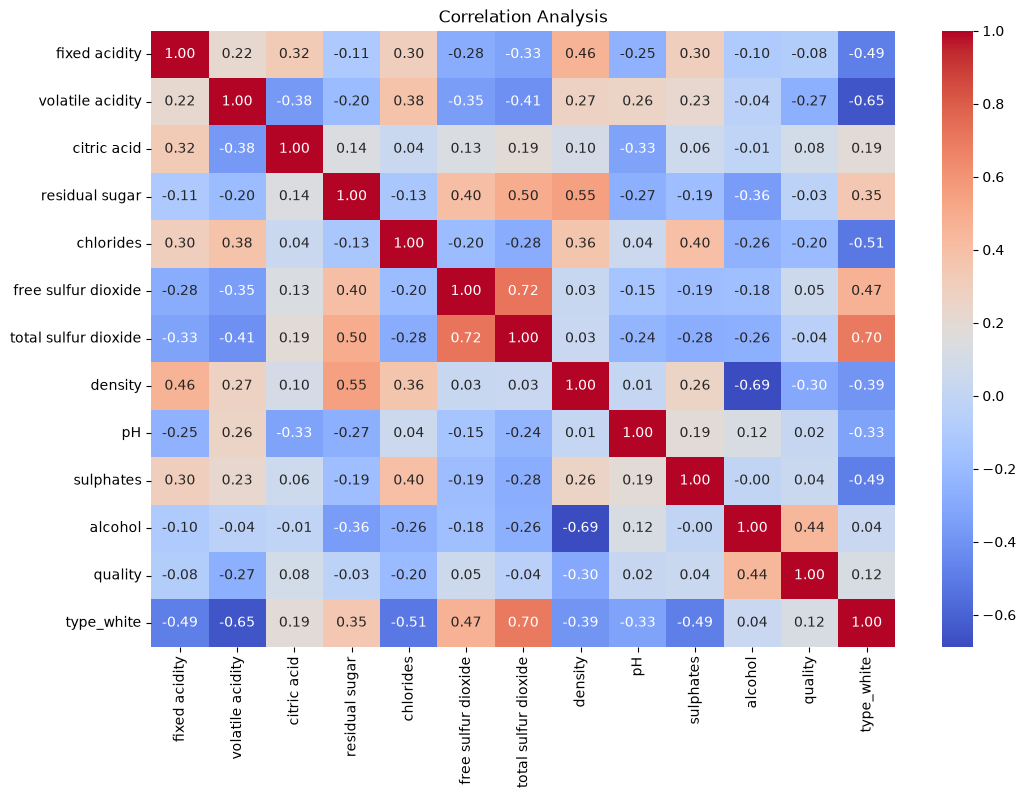

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis')
plt.show()

## 3. Model Implementation
We use a **Random Forest Classifier** to predict wine quality based on 
the physicochemical properties identified above.

In [9]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Define the models
model_list = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Support Vector Machine": SVC(random_state=42)
}

# 2. Train and evaluate each model
results = {}

for name, model in model_list.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    results[name] = accuracy
    print(f"{name} achieved: {accuracy:.2f} accuracy")

# 3. Identify the winner
best_model_name = max(results, key=results.get)
print(f"\n--- The Winner is: {best_model_name} with {results[best_model_name]:.2f} ---")

Random Forest achieved: 0.67 accuracy


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression achieved: 0.53 accuracy
Gradient Boosting achieved: 0.58 accuracy
Support Vector Machine achieved: 0.42 accuracy

--- The Winner is: Random Forest with 0.67 ---


### Model Training Results Summary

**Best Performing Model:** `Random Forest`  
**Achieved Accuracy:** `0.67`

---

#### 1. Benchmarking Overview
After evaluating four algorithms, the **Random Forest** classifier emerged as the most effective, achieving an accuracy of **0.67**. 

#### 2. Technical Observations
* **Data Scaling:** Models such as Logistic Regression and SVM required data standardization (`StandardScaler`) to reach convergence.
* **Model Selection:** While other models were tested for benchmarking, **Random Forest** demonstrated superior baseline performance on the provided feature set without requiring additional preprocessing pipelines.
* **Results:** The final accuracy of **0.67** provides a stable foundation for the wine quality prediction web application.

#### 3. Deployment
The **Random Forest** model has been serialized to `wine_model.pkl` and is ready for production.

In [11]:
import joblib

# This extracts the Random Forest model from your dictionary and saves it
joblib.dump(model_list["Random Forest"], 'wine_model.pkl')

print("Success! The 'Random Forest' model has been saved as 'wine_model.pkl'.")

Success! The 'Random Forest' model has been saved as 'wine_model.pkl'.
